In [1]:
# Text Preprocessing & TF-IDF

In [6]:
#  Imports & NLTK Setup

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer

pd.set_option('display.max_colwidth', 80)

In [4]:
# Dataset


positive_phrases = [
    "I absolutely loved this movie, it was fantastic",
    "Amazing product, works perfectly and exceeded expectations",
    "Great quality and fast shipping, highly recommend",
    "This was a wonderful experience from start to finish",
    "Best purchase I have made this year, so happy",
    "The acting was superb and the story kept me hooked",
    "Excellent value for money, will buy again",
    "Fantastic customer service and a great product overall",
    "I really enjoyed every minute of this film",
    "Outstanding performance, truly a masterpiece",
    "This gadget is incredibly useful and well designed",
    "Loved the plot twists, one of the best films I have seen",
    "The food was delicious and the staff were friendly",
    "Perfect fit, comfortable, and looks great too",
    "A brilliant read, could not put the book down",
    "Superb build quality, feels premium and durable",
    "The customer support team resolved my issue quickly and kindly",
    "Highly satisfied with this purchase, five stars",
    "This is hands down the best restaurant in town",
    "Wonderful cinematography and an emotional soundtrack",
]

negative_phrases = [
    "This movie was boring and a complete waste of time",
    "Terrible product, broke after one day of use",
    "Poor quality and the shipping took forever",
    "This was a disappointing experience overall",
    "Worst purchase I have made this year, regret it",
    "The acting was awful and the story made no sense",
    "Overpriced for what you actually get, not worth it",
    "Horrible customer service and a defective product",
    "I hated every minute of this film, so dull",
    "Bad performance, truly forgettable and boring",
    "This gadget is completely useless and badly designed",
    "The plot was predictable and honestly quite bad",
    "The food was cold and the staff were rude",
    "Terrible fit, uncomfortable, and looks cheap",
    "A dreadful read, I could not finish the book",
    "Flimsy build quality, feels cheap and fragile",
    "The customer support team ignored my issue for weeks",
    "Very disappointed with this purchase, one star",
    "This is easily the worst restaurant I have visited",
    "Dull cinematography and an annoying soundtrack",
]

# Expand dataset with light variation for a larger, more realistic sample size
intensifiers = ["", "Honestly, ", "To be fair, ", "Overall, ", "In my opinion, "]

reviews, sentiments = [], []
rng = np.random.RandomState(42)
for _ in range(5):
    for p in positive_phrases:
        prefix = intensifiers[rng.randint(len(intensifiers))]
        reviews.append(prefix + p + ".")
        sentiments.append(1)
    for n in negative_phrases:
        prefix = intensifiers[rng.randint(len(intensifiers))]
        reviews.append(prefix + n + ".")
        sentiments.append(0)

df = pd.DataFrame({'review': reviews, 'sentiment': sentiments})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle
print("Dataset shape:", df.shape)
print("Class balance:\n", df['sentiment'].value_counts())
df.head(8)

Dataset shape: (200, 2)
Class balance:
 sentiment
1    100
0    100
Name: count, dtype: int64


,review,sentiment
0,"To be fair, Superb build quality, feels premiu...",1
1,"Honestly, Superb build quality, feels premium ...",1
2,"To be fair, This gadget is completely useless ...",0
3,This is easily the worst restaurant I have vis...,0
4,"In my opinion, I really enjoyed every minute o...",1
5,"In my opinion, Flimsy build quality, feels che...",0
6,"Overall, Bad performance, truly forgettable an...",0
7,This gadget is incredibly useful and well desi...,1


In [ ]:
# Text Preprocessing Pipeline

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()  # shown for comparison only

def preprocess_text(text, use_lemmatization=True):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove punctuation and numbers, keep only letters and spaces
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. Tokenize
    tokens = word_tokenize(text)
    # 4. Remove stopwords (and very short leftover tokens)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    # 5. Lemmatize (or stem, for comparison)
    if use_lemmatization:
        tokens = [lemmatizer.lemmatize(t, pos='v') for t in tokens]
        tokens = [lemmatizer.lemmatize(t, pos='n') for t in tokens]
    else:
        tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

# Demo on one example
sample = df['review'].iloc[0]
print("Original: ", sample)
print("Lemmatized:", preprocess_text(sample, use_lemmatization=True))
print("Stemmed:   ", preprocess_text(sample, use_lemmatization=False))

Original:  To be fair, Superb build quality, feels premium and durable.
Lemmatized: fair superb build quality feel premium durable
Stemmed:    fair superb build qualiti feel premium durabl


In [8]:
df['clean_review'] = df['review'].apply(lambda t: preprocess_text(t, use_lemmatization=True))
df[['review', 'clean_review']].head(8)

,review,clean_review
0,"To be fair, Superb build quality, feels premium and durable.",fair superb build quality feel premium durable
1,"Honestly, Superb build quality, feels premium and durable.",honestly superb build quality feel premium durable
2,"To be fair, This gadget is completely useless and badly designed.",fair gadget completely useless badly design
3,This is easily the worst restaurant I have visited.,easily worst restaurant visit
4,"In my opinion, I really enjoyed every minute of this film.",opinion really enjoy every minute film
5,"In my opinion, Flimsy build quality, feels cheap and fragile.",opinion flimsy build quality feel cheap fragile
6,"Overall, Bad performance, truly forgettable and boring.",overall bad performance truly forgettable bore
7,This gadget is incredibly useful and well designed.,gadget incredibly useful well design


In [9]:
# Vocabulary Inspection

from collections import Counter

all_tokens = ' '.join(df['clean_review']).split()
word_freq = Counter(all_tokens)

print("Vocabulary size after cleaning:", len(word_freq))
print("\nTop 15 most frequent tokens:")
for word, count in word_freq.most_common(15):
    print(f"  {word:15s} {count}")

Vocabulary size after cleaning: 133

Top 15 most frequent tokens:
  overall         59
  honestly        40
  fair            37
  opinion         36
  quality         20
  purchase        20
  customer        20
  product         20
  film            15
  great           15
  best            15
  make            15
  one             15
  superb          10
  build           10


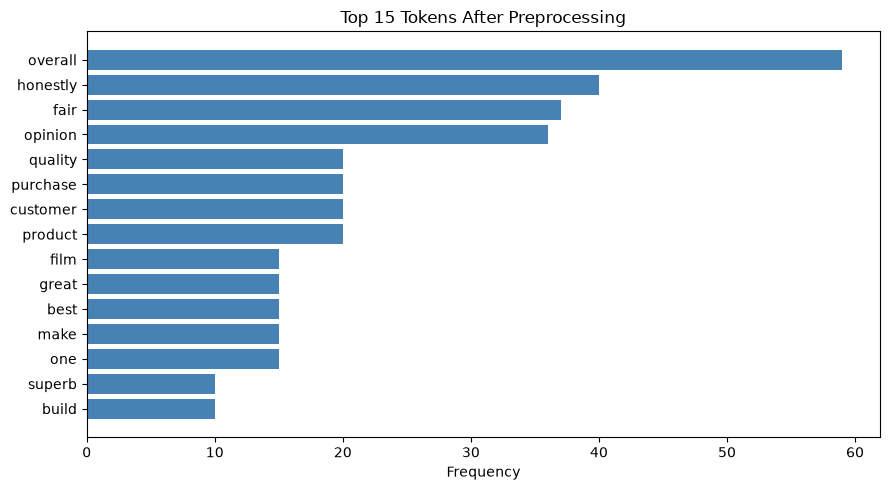

In [10]:
top_words = word_freq.most_common(15)
words, counts = zip(*top_words)

plt.figure(figsize=(9,5))
plt.barh(words[::-1], counts[::-1], color='steelblue')
plt.xlabel("Frequency")
plt.title("Top 15 Tokens After Preprocessing")
plt.tight_layout()
plt.show()

In [11]:
# TF-IDF Vectorization

In [12]:
tfidf = TfidfVectorizer(
    max_features=500,   # cap vocabulary size
    ngram_range=(1, 2), # unigrams + bigrams (captures phrases like 'not good')
    min_df=2            # ignore terms appearing in fewer than 2 documents
)

X_tfidf = tfidf.fit_transform(df['clean_review'])
y = df['sentiment'].values

print("TF-IDF matrix shape:", X_tfidf.shape)
print("Sparsity: {:.2%} non-zero".format(X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])))

TF-IDF matrix shape: (200, 320)
Sparsity: 3.16% non-zero


In [13]:
# Inspect TF-IDF scores for one example document
feature_names = tfidf.get_feature_names_out()
doc_idx = 0
doc_vector = X_tfidf[doc_idx].toarray().flatten()
top_indices = doc_vector.argsort()[-8:][::-1]

print("Review:", df['review'].iloc[doc_idx])
print("Cleaned:", df['clean_review'].iloc[doc_idx])
print("\nTop TF-IDF terms in this document:")
for idx in top_indices:
    if doc_vector[idx] > 0:
        print(f"  {feature_names[idx]:20s} {doc_vector[idx]:.4f}")

Review: To be fair, Superb build quality, feels premium and durable.
Cleaned: fair superb build quality feel premium durable

Top TF-IDF terms in this document:
  fair superb          0.3487
  superb build         0.3022
  premium durable      0.3022
  premium              0.3022
  feel premium         0.3022
  durable              0.3022
  build quality        0.2616
  build                0.2616


In [14]:
# Compare average TF-IDF weight of a few sentiment-carrying words across the corpus
import pandas as pd

sample_words = ['love', 'great', 'terrible', 'bad', 'amaze', 'boring']
word_to_idx = {w: i for i, w in enumerate(feature_names)}

for w in sample_words:
    if w in word_to_idx:
        col = X_tfidf[:, word_to_idx[w]].toarray().flatten()
        nonzero_mean = col[col > 0].mean() if (col > 0).any() else 0
        print(f"{w:10s} -> appears in {int((col>0).sum())} docs, mean TF-IDF when present: {nonzero_mean:.4f}")
    else:
        print(f"{w:10s} -> not in vocabulary (filtered by min_df or max_features)")

love       -> appears in 10 docs, mean TF-IDF when present: 0.2905
great      -> appears in 15 docs, mean TF-IDF when present: 0.2541
terrible   -> appears in 10 docs, mean TF-IDF when present: 0.2758
bad        -> appears in 10 docs, mean TF-IDF when present: 0.2899
amaze      -> appears in 5 docs, mean TF-IDF when present: 0.3066
boring     -> not in vocabulary (filtered by min_df or max_features)


In [15]:
# Save Processed Data 

df.to_csv('sentiment_dataset_clean.csv', index=False)
print("Saved sentiment_dataset_clean.csv —", df.shape[0], "rows")
print(df[['clean_review','sentiment']].sample(5, random_state=1))

Saved sentiment_dataset_clean.csv — 200 rows
                                     clean_review  sentiment
58         honestly food delicious staff friendly          1
40   overall dull cinematography annoy soundtrack          0
34         gadget completely useless badly design          0
102        overall poor quality ship take forever          0
184           plot predictable honestly quite bad          0
